<h2> Прогнозирование размеров сварного шва при электронно-лучевой сварке тонкостенных конструкций аэрокосмического назначения</h2>

В данной работе проведён анализ влияния параметров сварки (ток, напряжение, скорость, мощность пучка) на размеры сварного шва (глубину и ширину).

Важной частью работы стал этап EDA, который позволил нам увидеть, что информативных признаков для построения моделей в нашем датасете не так много (как оказлось воспледствии датасет был искуственно размножен), игнорированние данного факта могло привести к неправильной оценке функционала ошибки модели, ведь в тестовую выборку могли попасть ровно те же значения, на которых тренировалась модель. 

Построение моделей на уникальных информативных признаках и её оценка методом LOOCV, подтвердило нашу догадку, лучшие модели, построенные на неочищенных данных показали худшее качество при данном типе тестирования. В итоге была выбрана OLS модель, оптимизированная на малом наборе данных методом LOOCV,   MAE модели составили <b>.11</b> для глубины , и <b>.07</b> для ширины сварного шва, что удовлетворяло требованием заказчика!

<div style="text-align: right"> <b>(2023)</b> </div>

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
# импортируем необходимые библиотеки для разведочного анализа
sns.set_style('whitegrid')

In [ ]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [ ]:
data=pd.read_csv('ebw_data.csv') #загружаем наш датасет
data.sample(5)

,IW,IF,VW,FP,Depth,Width
30,47,139,4.500,80,1.400,2.480
52,43,150,9.000,50,1.080,1.800
36,49,132,8.000,125,0.840,2.280
19,46,141,10.000,80,1.160,1.800
32,48,131,10.000,125,0.840,2.160


In [173]:
img=dict(data[['Depth','Width']])
with open('img.json', 'wb') as file:
     pickle.dump(img, file)

<h3>I. Поиск пропущенных значений</h3>

In [ ]:
data.isna().sum() #Проверка на наличие пропусков в данных
#пропусков нет

IW       0
IF       0
VW       0
FP       0
Depth    0
Width    0
dtype: int64

<h3>II. Разведочный анализ данных</h3> </div>

In [ ]:
data.describe().iloc[1:] #убрали неинформативную строку count
#в целом мы видиим разный масштаб данных, что говорит нам о необходимости проведения нормализации

,IW,IF,VW,FP,Depth,Width
mean,45.667,141.333,8.639,78.333,1.196,1.970
std,1.678,5.146,2.061,21.494,0.225,0.279
min,43.000,131.000,4.500,50.000,0.800,1.680
25%,44.000,139.000,8.000,60.000,1.080,1.760
50%,45.500,141.000,9.000,80.000,1.200,1.840
75%,47.000,146.000,10.000,80.000,1.290,2.050
max,49.000,150.000,12.000,125.000,1.760,2.600


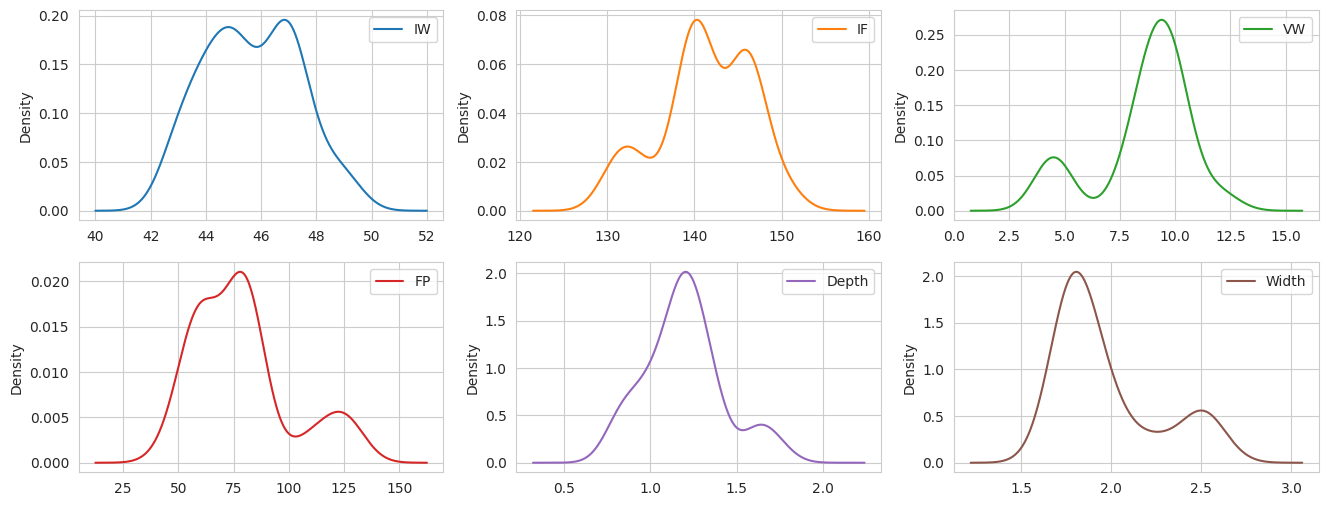

In [ ]:
data.plot(kind='density',subplots=True,layout=(2,3),figsize=(16, 6),sharex=False);
#смотрим на распределение


 
Мы видим, что большинство переменных имеет <a href="https://www.codecamp.ru/blog/multimodal-distribution/">мультимодальное распределение</a>, это говорит о потенциале к разбиению данных на категориальные признаки, также о том, что мы бы не могли пользоваться медианой и средним при заполнении пропусков в данных  <i>(которых, к счастью, нет) </i>



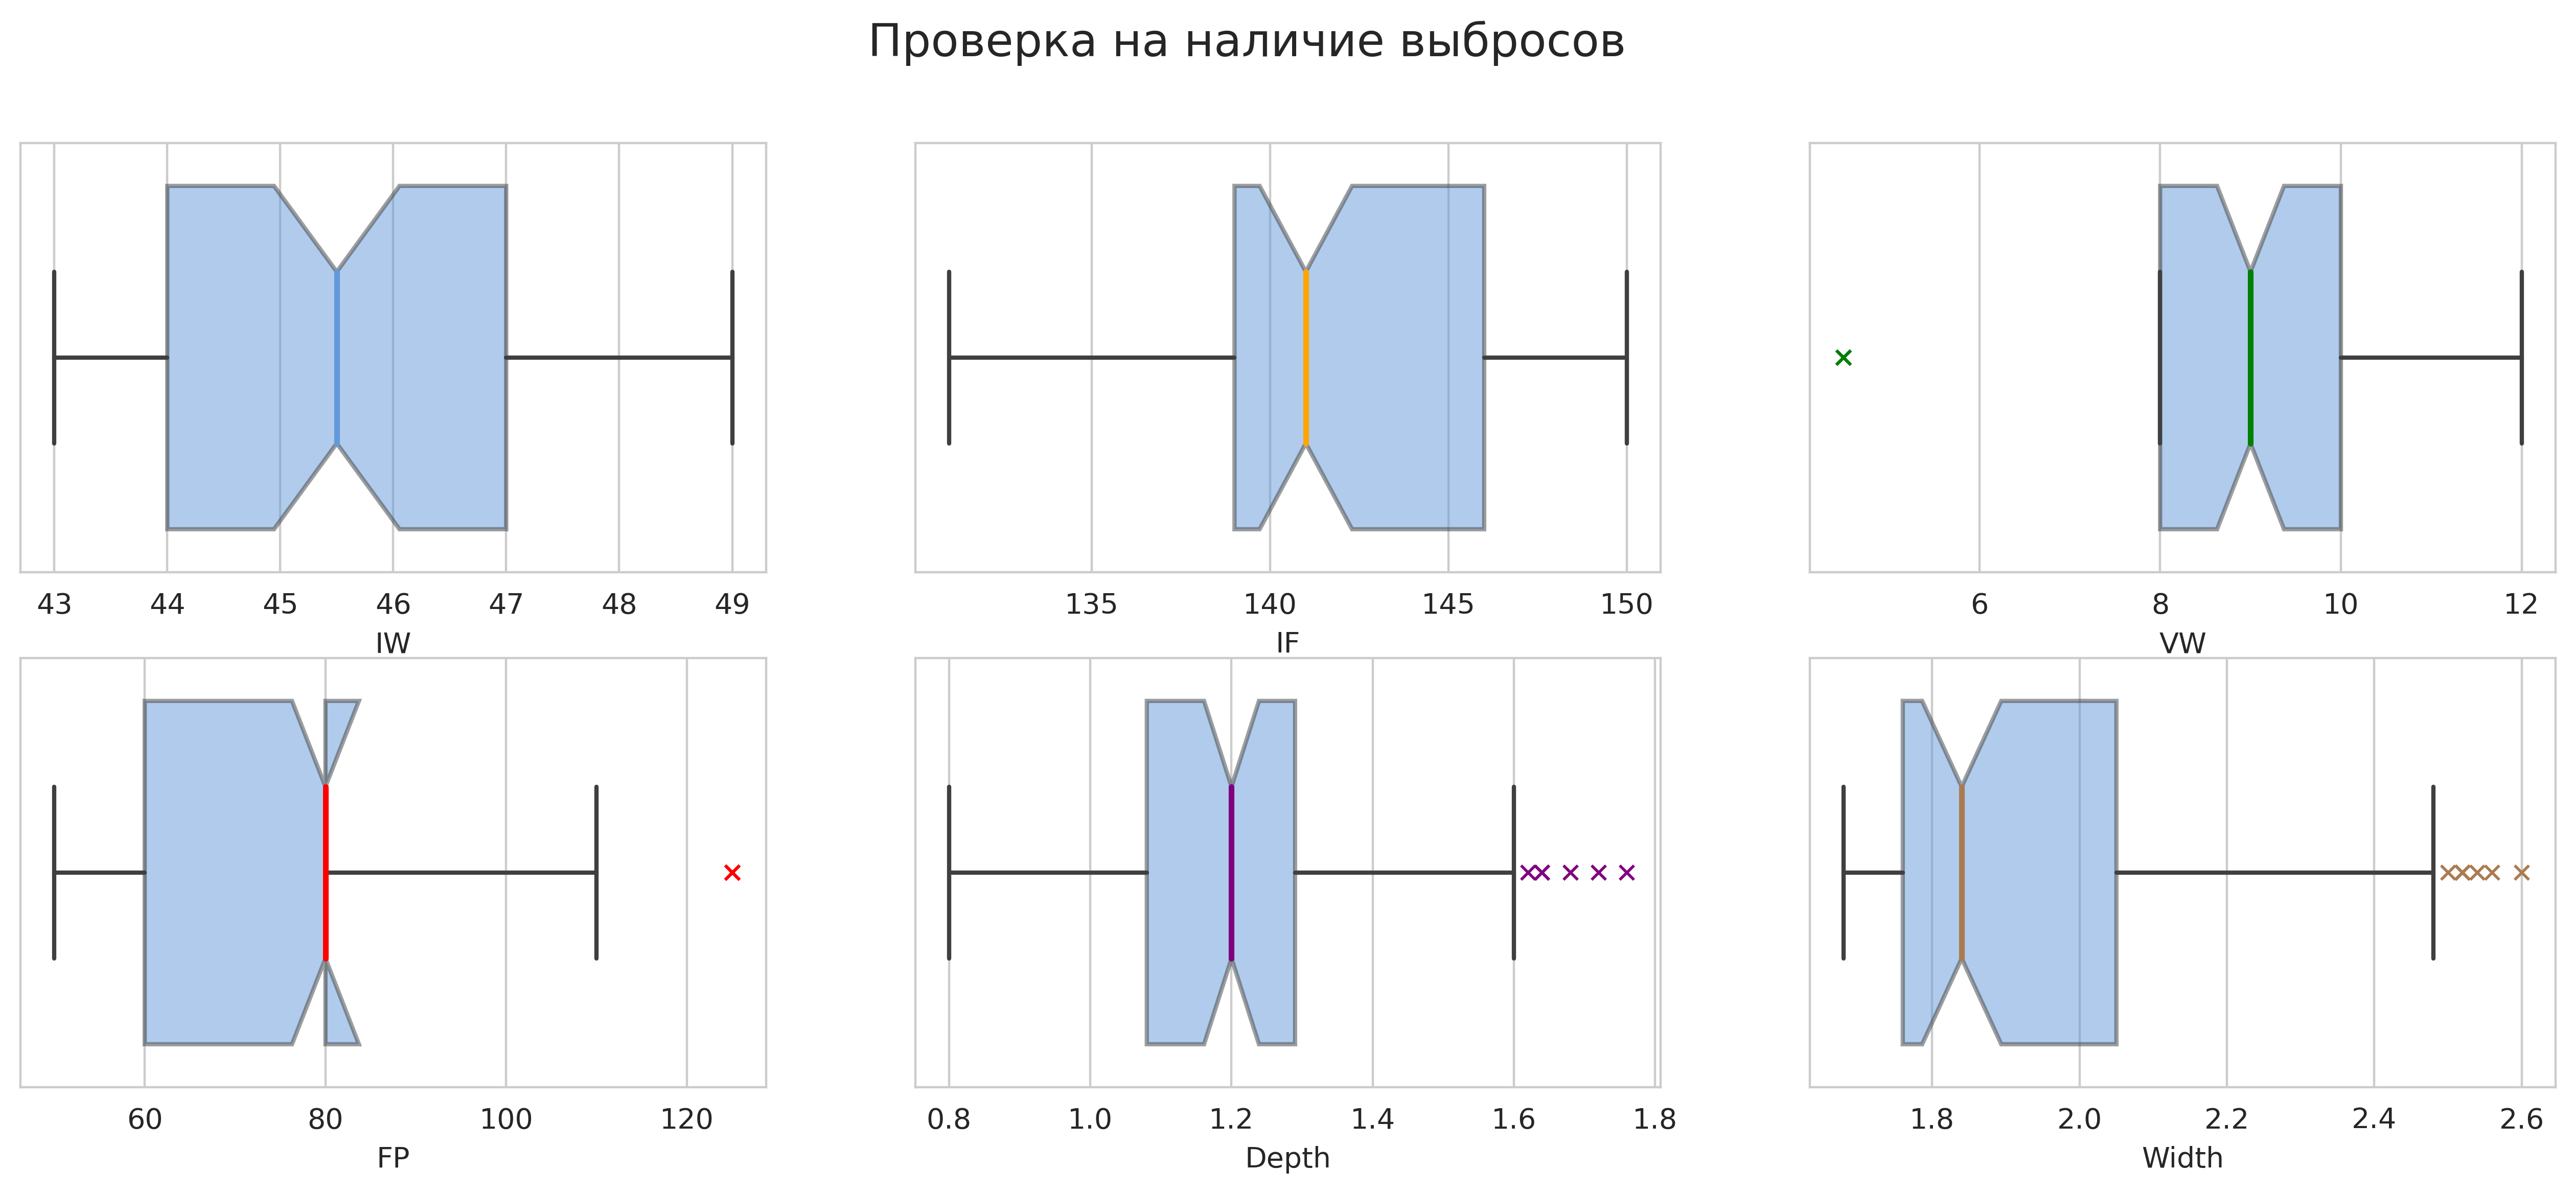

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 6), dpi=400,sharex=False)
fig.suptitle('Проверка на наличие выбросов',fontsize=16)

axs=[(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]
clrs=['#6299d9','orange','green','red','purple','#ab7b50']

for i in range(0,6):
    sns.boxplot(ax=axes[axs[i]], x=data[data.columns[i]],
               notch=True,
               flierprops={"marker": "x","markeredgecolor": clrs[i]},
               boxprops={"facecolor": '#6299d9','alpha':0.5},
               medianprops={"color": clrs[i],'linewidth':'2'})


Зная характер распределения признаков, мы можем говорить о том, что данные, отмеченные в боксплотах как выбросы, на самом деле вторые-верхушики бимодального распределения, и их достаточное кол-во от общего объёма  <i>(даже кажущиеся одинарными зелёный и красный крестики на самом деле — группа данных с одинаковым значением) </i>. Эти данные несут информативную статистику для нашего анализа, поэтому очистка датасетов от выбросов не требуется

In [ ]:
data.corr().where((data.corr().abs()>0.5)&
                  (data.corr().abs()!=1)).fillna('')
            #корреляционная таблица из которой исключена рябь неинформативных оценок

,IW,IF,VW,FP,Depth,Width
IW,,-0.861,,0.836,,
IF,-0.861,,,-0.981,,-0.510
VW,,,,,-0.671,-0.874
FP,0.836,-0.981,,,-0.511,
Depth,,,-0.671,-0.511,,
Width,,-0.510,-0.874,,,


<Axes: >

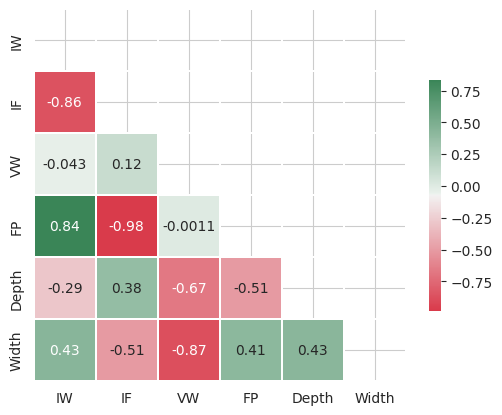

In [ ]:
corr = data.corr(numeric_only=True)
# Создадим маску для верхнего треугольника корреляции
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axes = plt.subplots(figsize=(6, 6))
cmap = sns.diverging_palette(9, 1220, as_cmap=True)# создадим colormap

sns.heatmap(corr, mask=mask, cmap=cmap,annot=True,
            square=True, linewidths=.3, cbar_kws={"shrink": .5})

Мы видим что все данные сильно скоррелированы друг с другом, в обычном статистическом анализе пришлось бы для каждой переменной строить отдельные модели, поскольку данная проблема смещает значения коэффицентов и делает расчёт p-value <a href="https://statisticsbyjim.com/regression/multicollinearity-in-regression-analysis/#:~:text=Multicollinearity%20makes%20it%20hard%20to,a%20way%20to%20fix%20multicollinearity.">не репрезентативным</a>, для целей предсказания мультиколлинеарность не является критичной проблемой, однако из-за данного явленяи наши доверительные интервалы станут шире

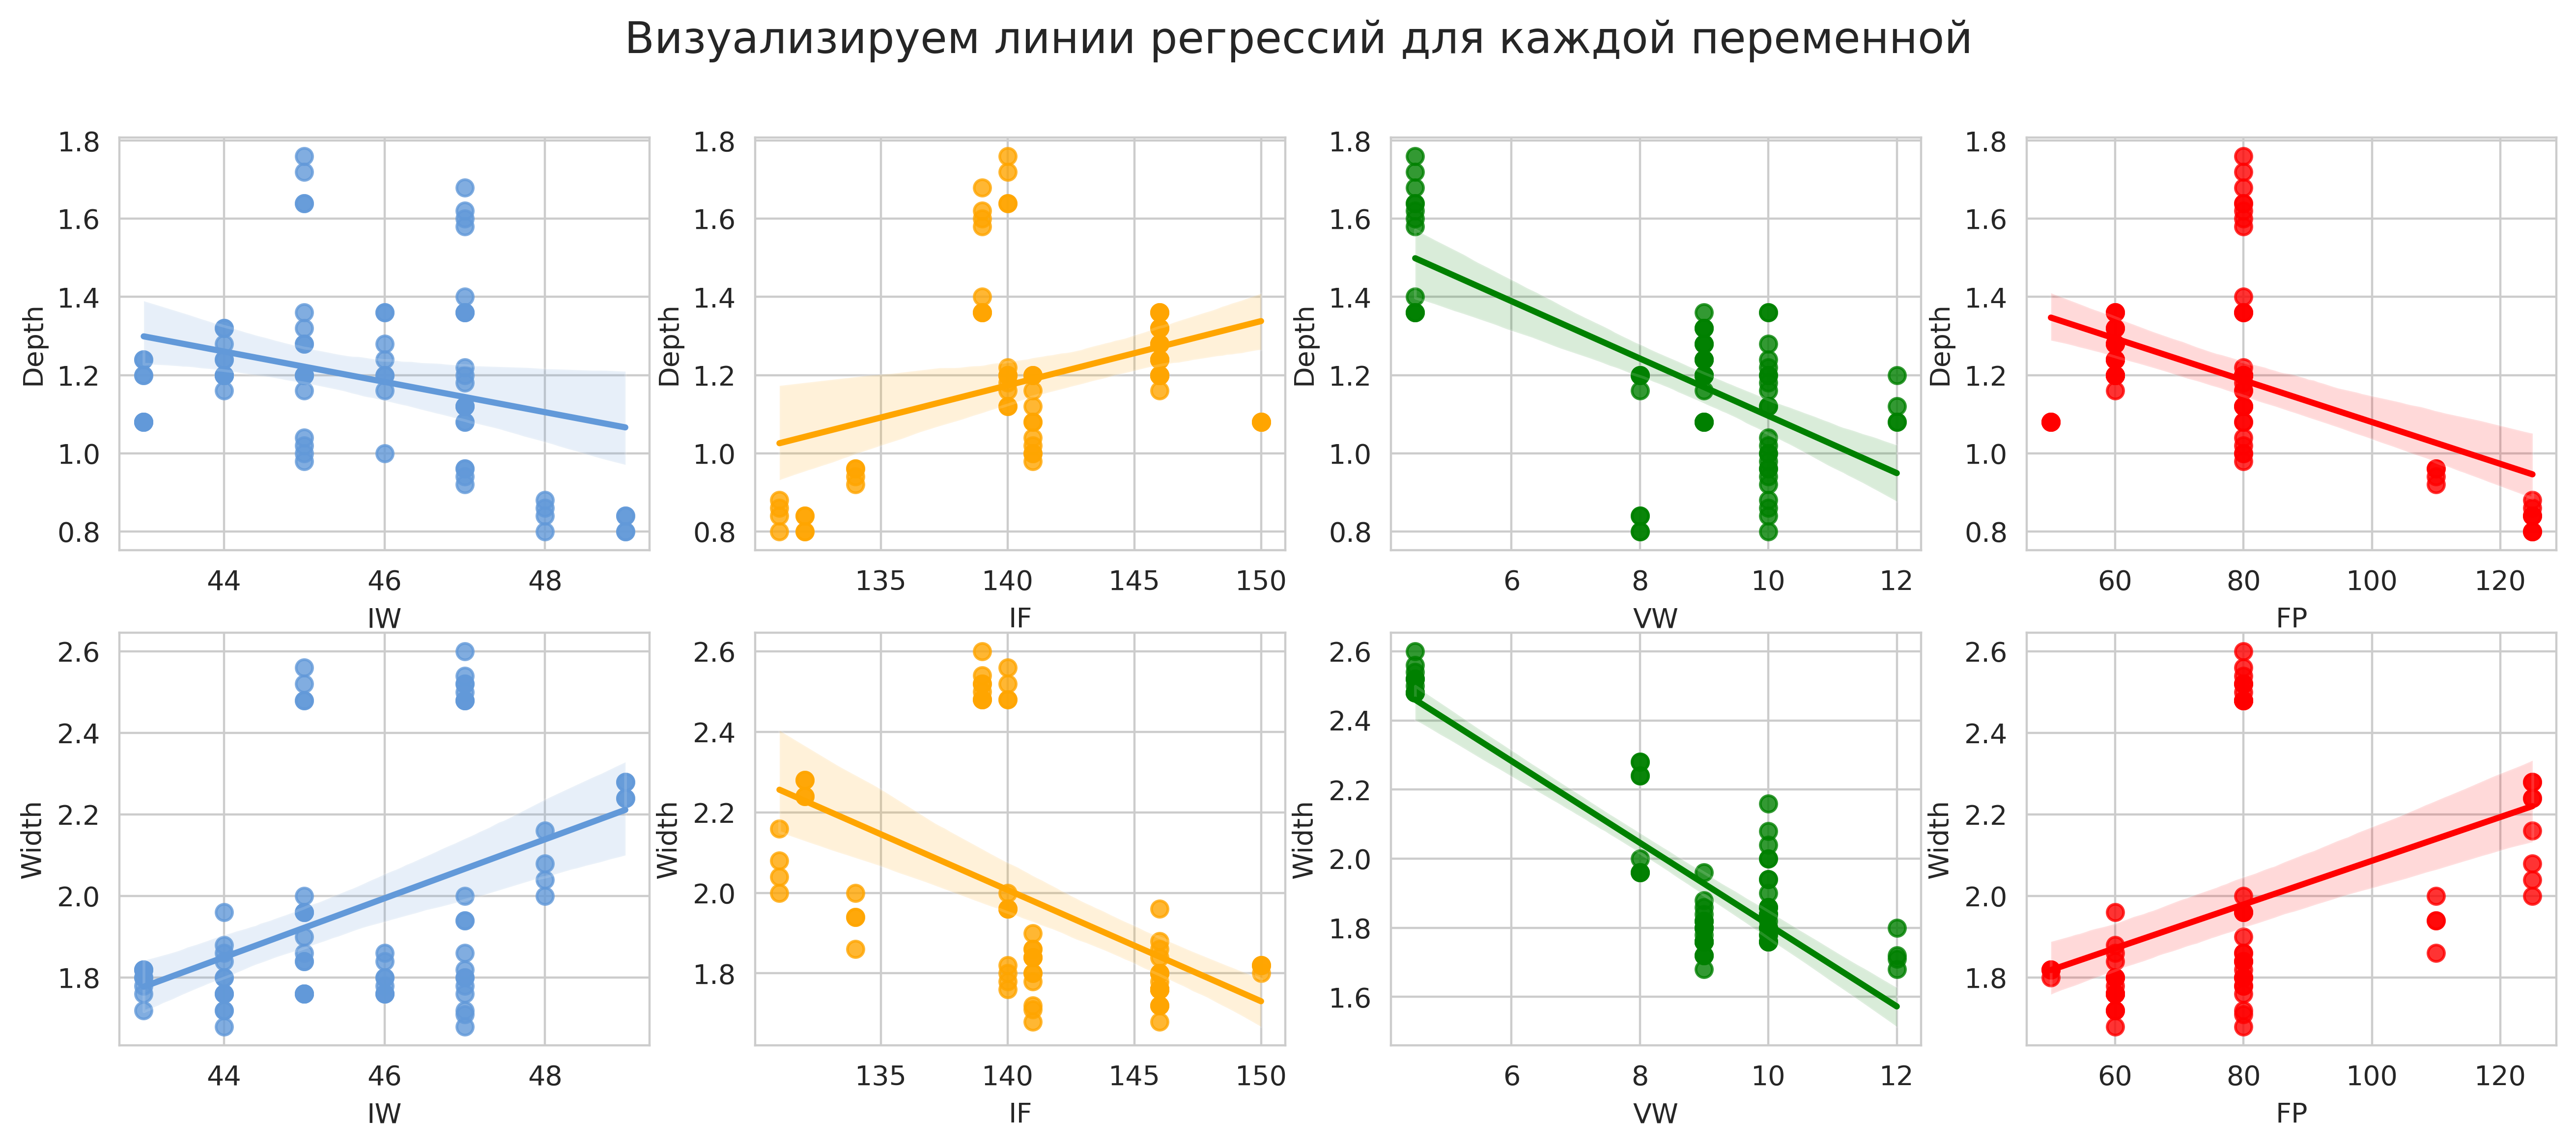

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6),dpi=400, sharex=False)
fig.suptitle('Визуализируем линии регрессий для каждой переменной',fontsize=16)
axs=[(0,0),(0,1),(0,2),(0,3)]
axs2=[(1,0),(1,1),(1,2),(1,3)]

clrs=['#6299d9','orange','green','red']

for i in range(0,4):
    iks=data[data.columns[i]]
    sns.regplot(data=data,x=iks,y=data.Depth,ax=axes[axs[i]],color=clrs[i], order=1)
    sns.regplot( data=data,x=iks,y=data.Width,ax=axes[axs2[i]],color=clrs[i],order=1)

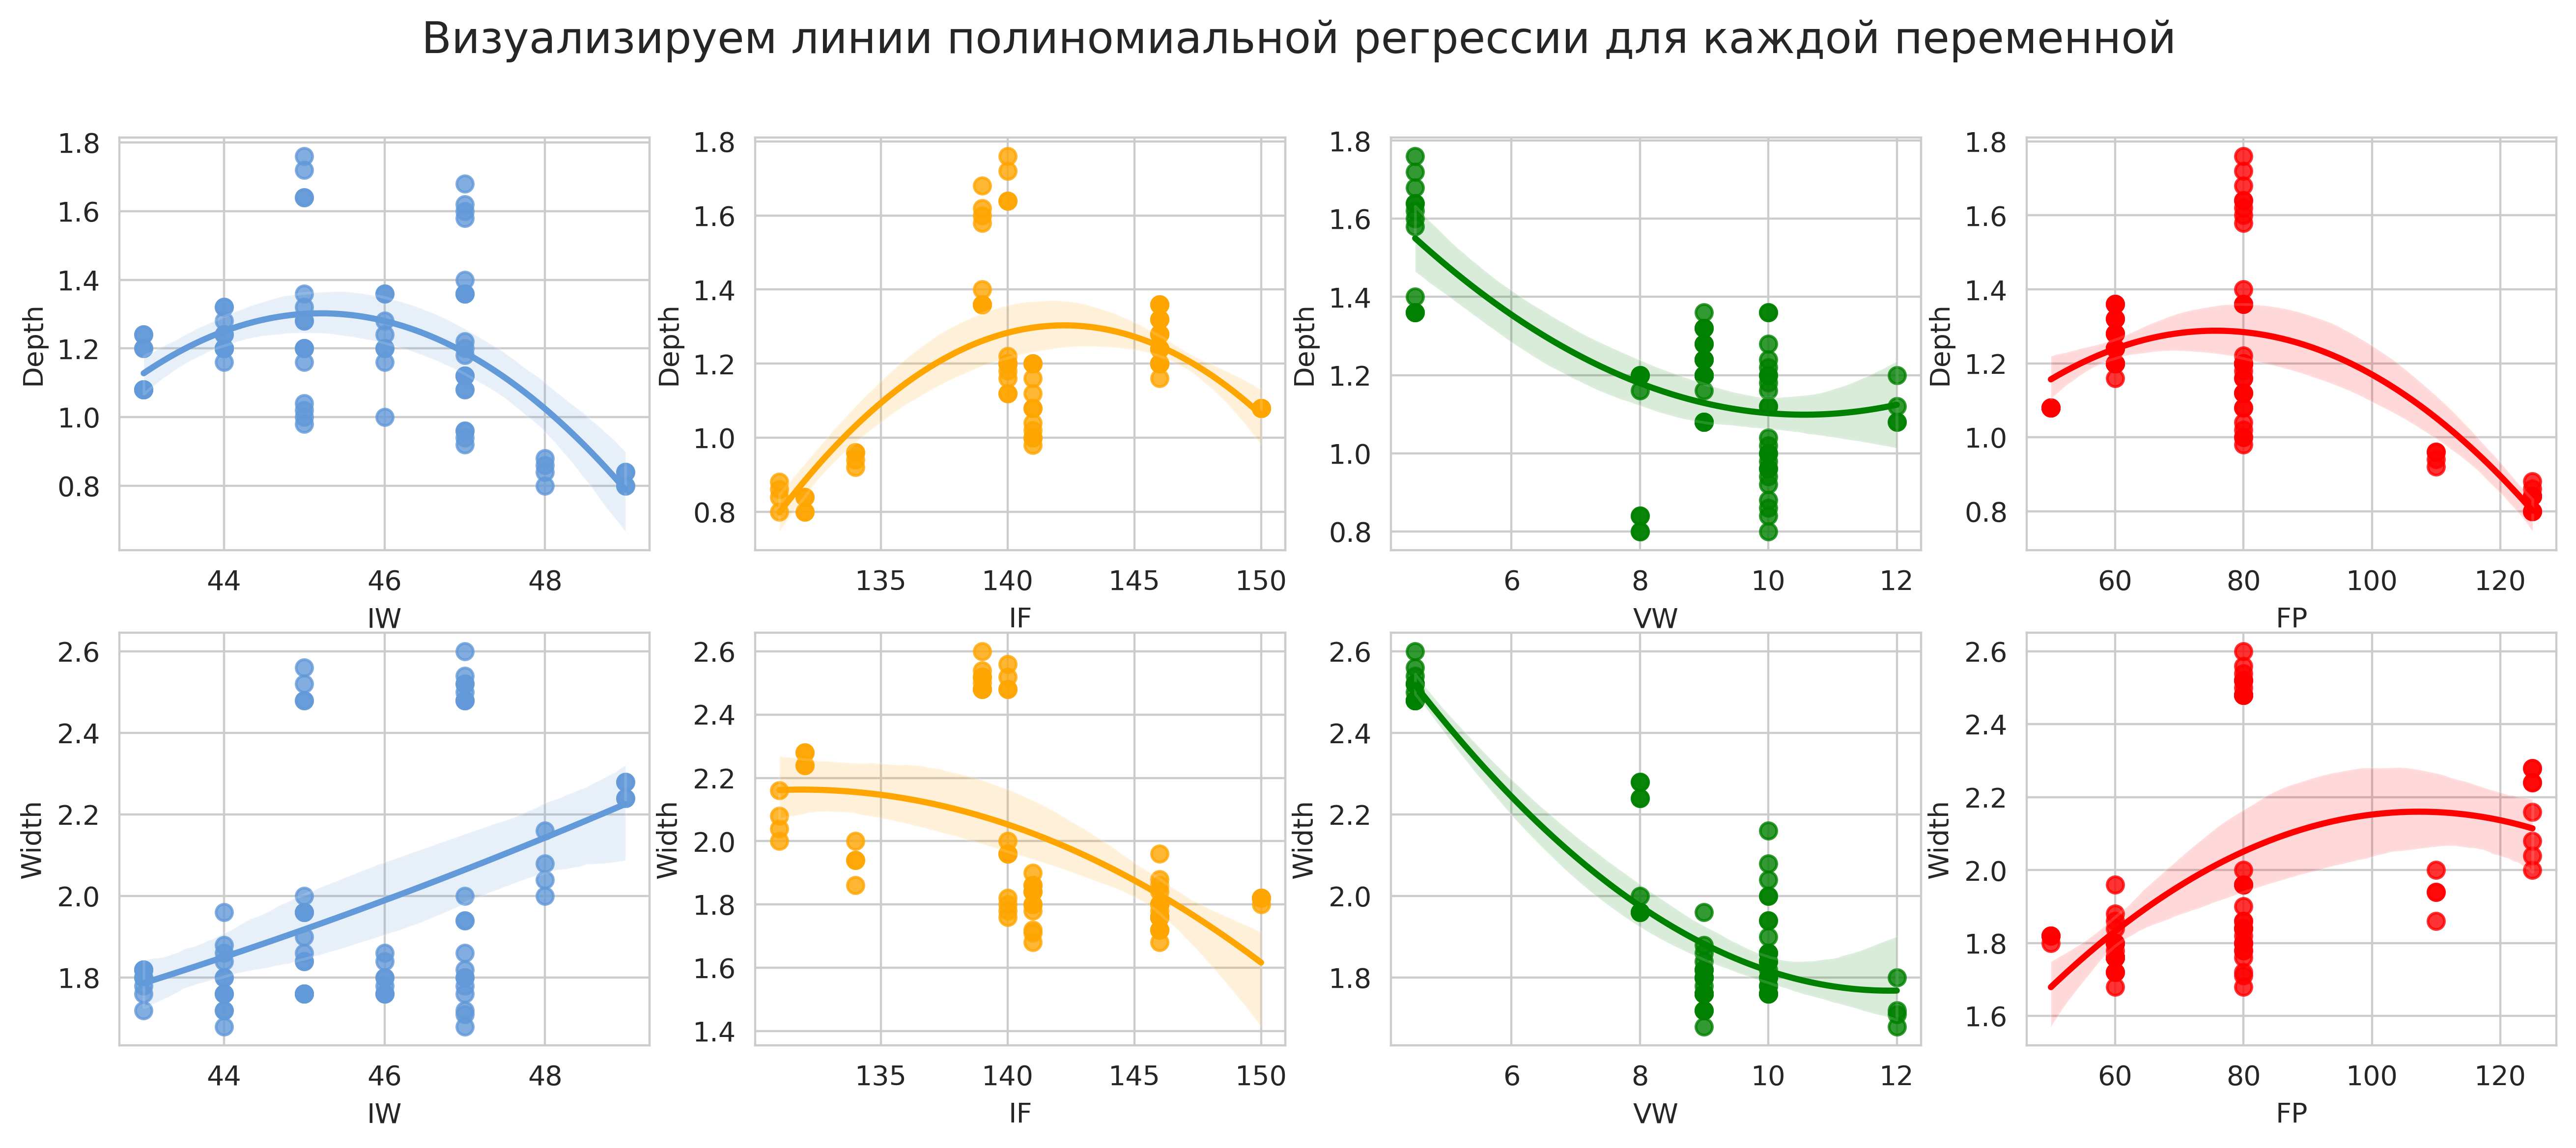

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6),dpi=400, sharex=False)
fig.suptitle('Визуализируем линии полиномиальной регрессии для каждой переменной',fontsize=16)
axs=[(0,0),(0,1),(0,2),(0,3)]
axs2=[(1,0),(1,1),(1,2),(1,3)]

clrs=['#6299d9','orange','green','red']

for i in range(0,4):
    iks=data[data.columns[i]]
    sns.regplot( data=data,x=iks,y=data.Depth,ax=axes[axs[i]],color=clrs[i], order=2)
    sns.regplot( data=data,x=iks,y=data.Width,ax=axes[axs2[i]],color=clrs[i],order=2)

Мы видим, что в данных, для обеих наших зависимых переменных действитело прослеживаются линейные зависимости, интересно что эти зависимости в $3/4$ случев имеют разнонаправленный характер <i>(увеличивая ширину, уменьшают глубину и наоборот) </i>, также можно заметить что полиномиальные регрессии <i>(2 порядка)</i> также рисуют неплохие аппроксимации зависимости переменных, примем это во внимание для дальнейшего построения моделей

Также графики показывают дискретный характер данных, как и бинмодальное распределение, это говорит нам о возможности разбиения признаков на категориальные данные, однако учитывая не большой размер датасета<i> (72 строки данных)</i> подобный фокус может привести нас к <a href="http://www.machinelearning.ru/wiki/index.php?title=%D0%9F%D1%80%D0%BE%D0%BA%D0%BB%D1%8F%D1%82%D0%B8%D0%B5_%D1%80%D0%B0%D0%B7%D0%BC%D0%B5%D1%80%D0%BD%D0%BE%D1%81%D1%82%D0%B8">проклятью размерности</a>, более того, есть подозрение на то, что на самом деле информативных признаков в датасете гораздо меньше. Проверим!

In [ ]:
data.groupby(['IW','IF','VW','FP']).agg(['mean','std','var','count']).reset_index()

IW   IF     VW   FP Depth                   Width                  
                         mean   std   var count  mean   std   var count
0   43  146  9.000   60 1.220 0.023 0.001     4 1.765 0.034 0.001     4
1   43  150  9.000   50 1.080 0.000 0.000     4 1.815 0.010 0.000     4
2   44  146  9.000   60 1.230 0.052 0.003    12 1.795 0.079 0.006    12
3   45  140  4.500   80 1.690 0.060 0.004     4 2.510 0.038 0.001     4
4   45  140  8.000   80 1.190 0.020 0.000     4 1.970 0.020 0.000     4
5   45  141 10.000   80 1.010 0.026 0.001     4 1.860 0.028 0.001     4
6   45  146  9.000   60 1.310 0.038 0.001     4 1.760 0.000 0.000     4
7   46  141 10.000   80 1.140 0.095 0.009     4 1.820 0.037 0.001     4
8   46  146 10.000   60 1.310 0.060 0.004     4 1.770 0.020 0.000     4
9   47  134 10.000  110 0.945 0.019 0.000     4 1.935 0.057 0.003     4
10  47  139  4.500   80 1.495 0.137 0.019     8 2.515 0.041 0.002     8
11  47  140 10.000   80 1.160 0.049 0.002     4 1.790 0.026 0.001     4
12  47  141 12.000   80 1.120 0.057 0.003     4 1.728 0.051 0.003     4
13  48  131 10.000  125 0.845 0.034 0.001     4 2.070 0.068 0.005     4
14  49  132  8.000  125 0.820 0.023 0.001     4 2.260 0.023 0.001     4

In [ ]:
data['new_column'] = data[['IW','IF','VW','FP']].values.tolist()
data['new_column']="Параметры сварки "+data['new_column'].astype(str)

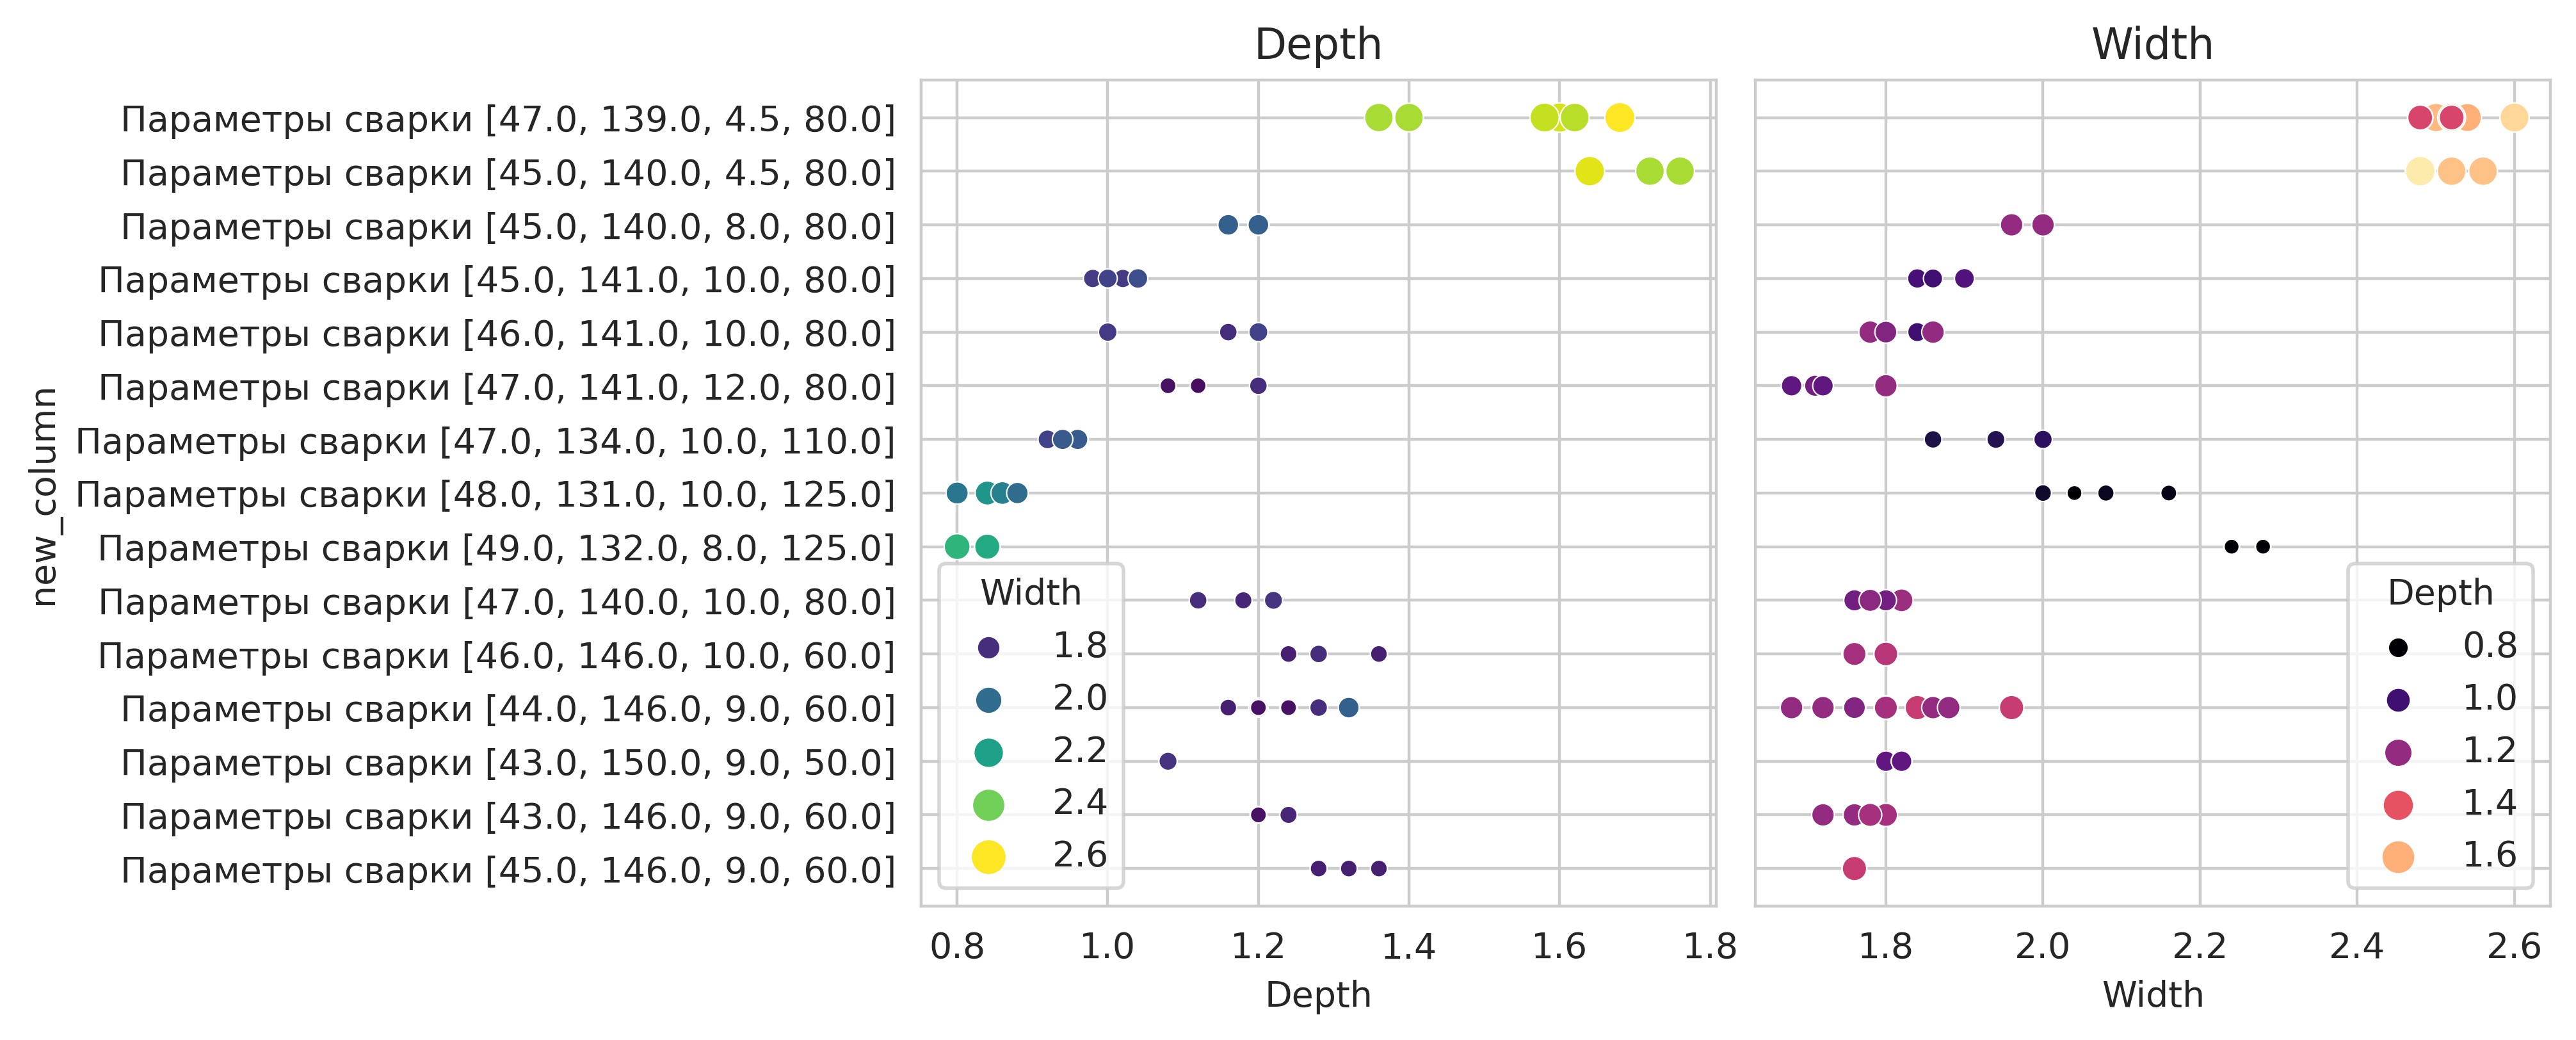

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4),dpi=400, sharey=True)

sns.scatterplot(ax=axes[0],data=data, x="Depth", y="new_column",hue='Width',palette="viridis",size='Width')
axes[0].set_title("Depth")


sns.scatterplot(ax=axes[1],data=data, x="Width", y="new_column",hue='Depth',palette="magma",size='Depth')
axes[1].set_title("Width")

fig.tight_layout(pad=.5)

Опасения подтвердилось, в датасете всего 15 информативных признаков, более того, одни и те же параметры могут приводить к разной глубине и ширине сварного шва, при некторых параметрах дисперсия зависимой переменной довольна высока. Это на берегу говорит нам о том, что потрясающего качества модели достичь нельзя, возможно пропущены какие-то значимые переменные, следовательно коэффицент детерминации модели также будет не велик.

Интереса ради, создадим датафрейм <b>data_small</b> с уникальными независимыми переменными, а для зависимых переменных усредним значения Глубины и Ширины шва, в дальнешйем пообучаем регрессионные модели и на этом небольшом датасете и предсказательную силу с моделями обучающимися на полной выборке

In [ ]:
data_small=data.groupby(['IW','IF','VW','FP']).agg('mean',numeric_only=True).reset_index()
data_small.columns=['IW','IF','VW','FP','avDepth','avWidth']

Мы помним, что у зависимых переменных тоже наблюдается небольшая корреляция <i>(.43)</i>, визуализируем линейную зависимость между ними


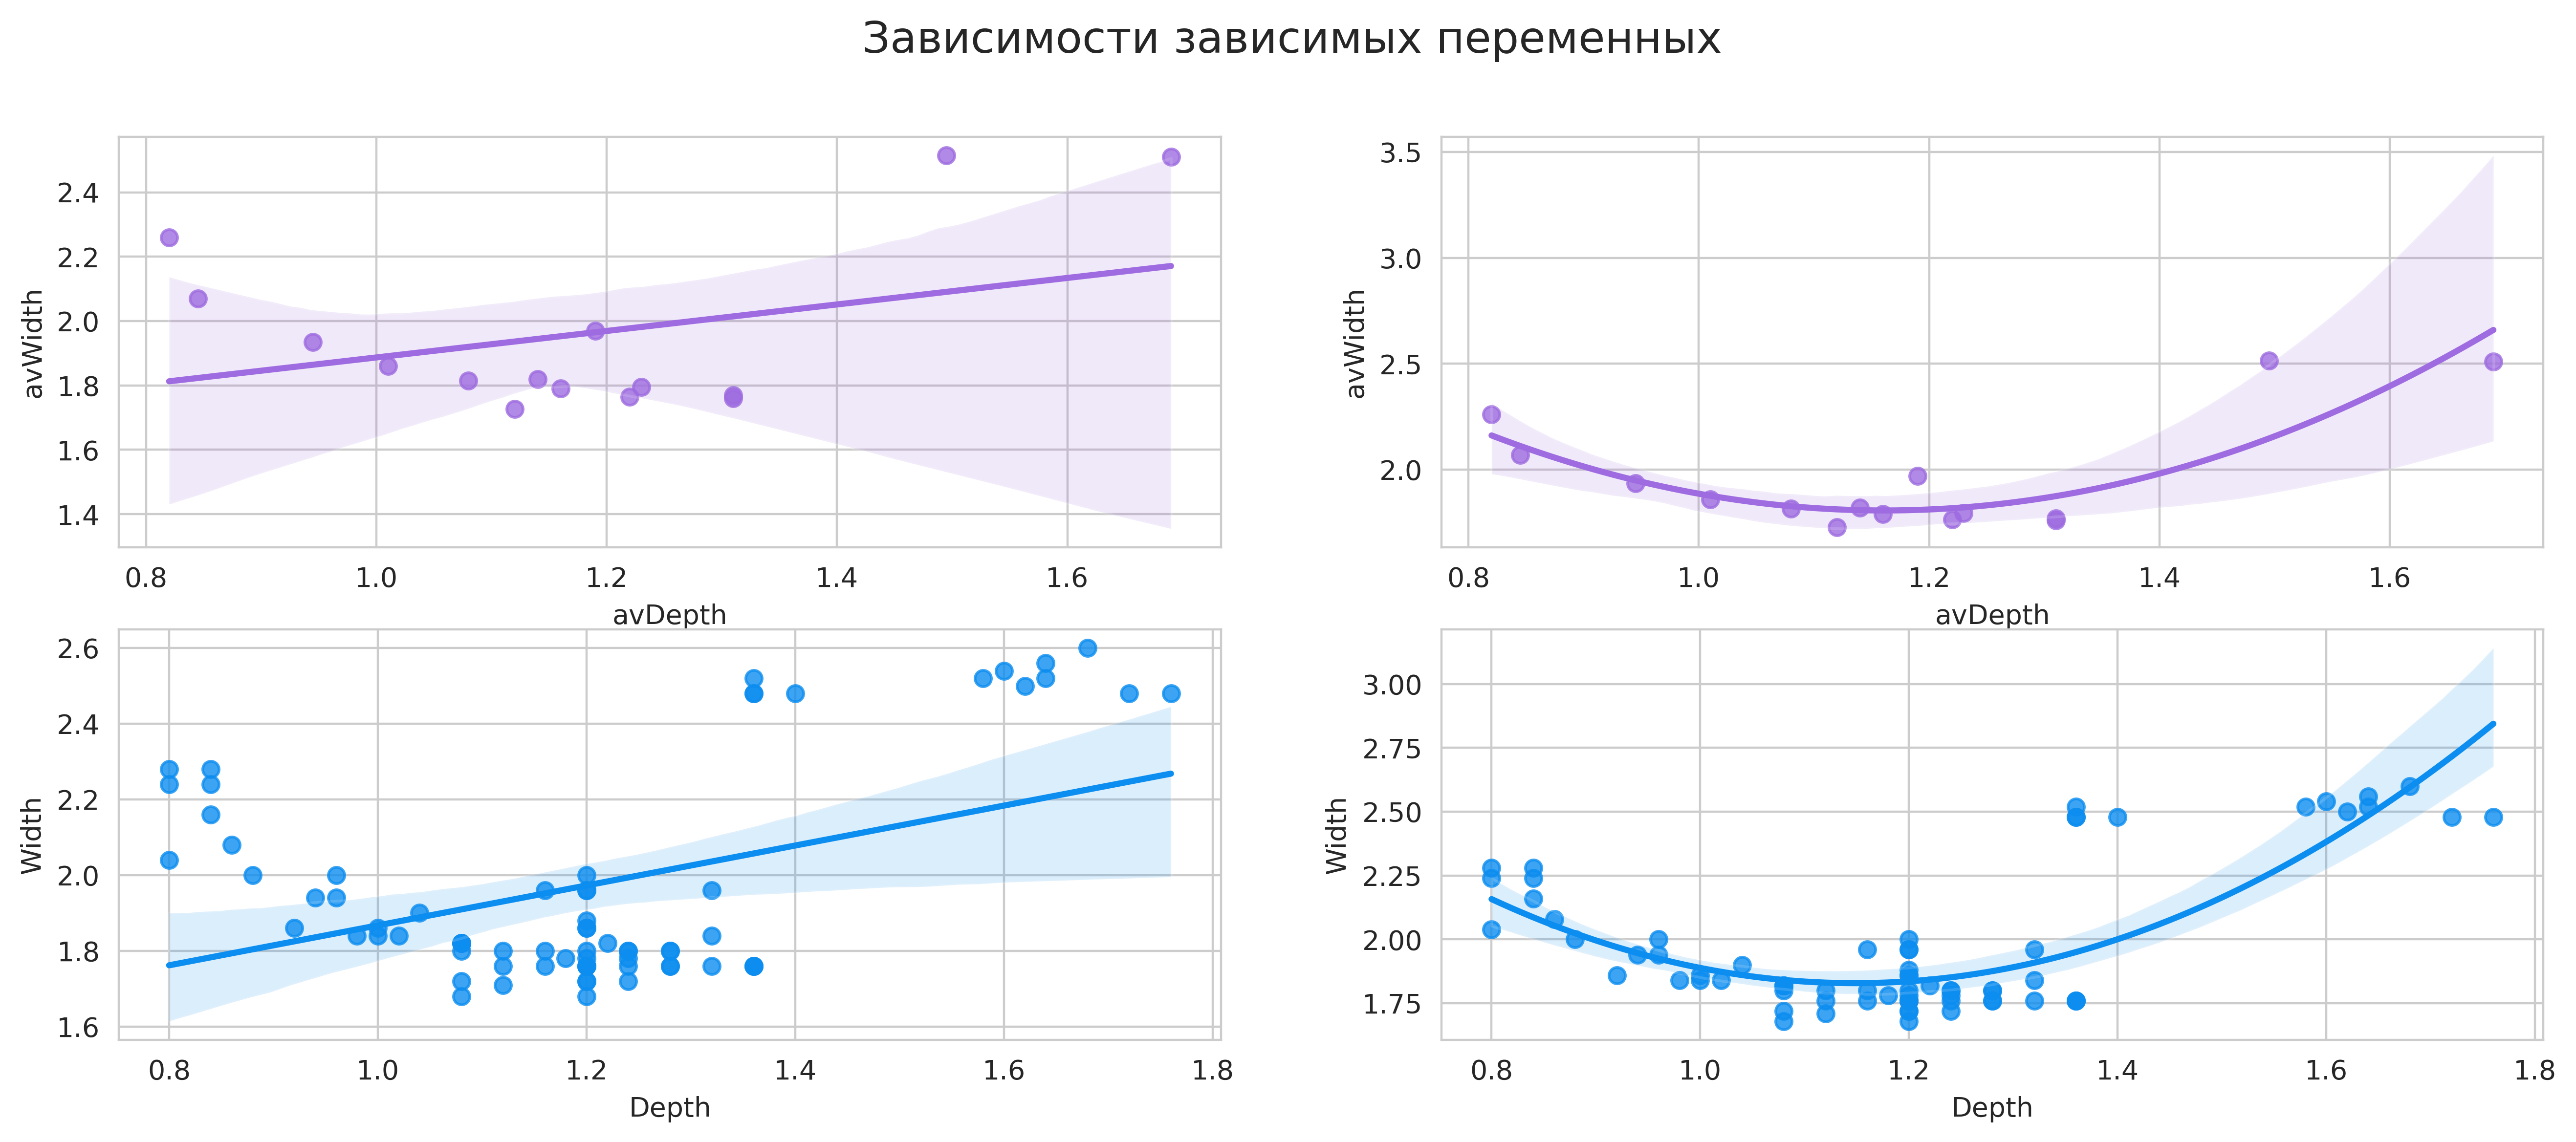

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 6),dpi=400, sharex=False)
fig.suptitle('Зависимости зависимых переменных',fontsize=16)
axs=[(0,0),(0,1)]
axs2=[(1,0),(1,1)]

for i in range(0,2):
    sns.regplot(data=data_small,x="avDepth",y="avWidth",ax=axes[axs[i]],color='#9e6ce0', order=i+1)
    sns.regplot(data=data,x="Depth",y="Width",ax=axes[axs2[i]],color='#0c8df0',order=i+1)

Графики подсказывают о нелинейной зависимости переменных <i>(возможно есть смысл включить предсказание по одной из переменных в независимые признаки для другой)</i>, также графики говорят о значительном увеличении доверительного интервала при построении регрессии на датасете <b>data_small</b>, что логично, учитывая низкую плотность данных.


<h3>III. Нормализация</h3>
Не стандартизация потому, что распределение признаков не Гауссовское

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
min_max_scaler = MinMaxScaler()

X=min_max_scaler.fit_transform(np.array(data[['IW','IF','VW','FP']]))
y_w=np.array(data.Width)
y_d=np.array(data.Depth)


Xs=min_max_scaler.fit_transform(np.array(data_small[['IW','IF','VW','FP']]))#Нормализуем иксы
ys_w=np.array(data_small.avWidth)
ys_d=np.array(data_small.avDepth)

In [ ]:
# import pickle
# maxim=dict(data[['IW','IF','VW','FP','Width']].max())
# minim=dict(data[['IW','IF','VW','FP','Width']].min())
# average=dict(data[['IW','IF','VW','FP','Width']].mean())
# #min_pols.append(df[df > 0].min().min())
# with open('maxim.json', 'wb') as file:
#     pickle.dump(maxim, file)

<h3>IV. Строим модели</h3> 

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
model_quality=[]# для создания датасета с качеством моделей

<h3>LinearRegression()</h3> 

Начнём со станадартной линейной регрессии, представленный внизу код, сто раз строит модели для каждой из зависимой переменной, а затем устредняет по ним функционал качества и коэффицент детерминации,такой топорный кросс-валидейшн был сделан постольку поскольку у нас мало данных и при повторном запуске одной и той же модели без указания <b>random_state</b> были замечены значительные флуктуации в оценках качества модели. Это говорит о неустойчивости регрессионной модели, небольшие потери в данных для тестовой выборки смещают её оценки. Топорным кроссвалидейшином ориетируясь на ЗБЧ мы можем представить более реальное представление о предсказательной мощности модели. Почему не cross-validation из библиотеки skir-learn, потому-что на проверку он оказался ещё более неустойчивым и чрезвычайно сильно зависел от кол-ва разбиений выборки!

In [ ]:
linear_model = LinearRegression()

for ygrik in [y_w,y_d]:
    MSE=[]
    MAE=[]
    R2=[]
    for i in range(1,100): # своебразный кросс валидейшн, больше напоминающий бутстреппинг
        # делается затем что оценки модели не постоянные
        # особенно r2_score
        X_train, X_test, y_train, y_test = train_test_split(X, ygrik, test_size=0.3,shuffle=True)
        model=linear_model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        R2.append(r2_score(y_test,y_pred))
        MAE.append(mean_absolute_error(y_test,y_pred))
        MSE.append(mean_squared_error(y_test,y_pred))

    #записываем данные в обощенный датасет моделей
    qual={
          'Model': 'LinearRegression',
          'Data': 'full',
          'Y': "depth" if str(y_d)==str(ygrik) else 'width',
          'MSE': round(np.mean(MSE),4),
          'MAE':round(np.mean(MAE),4),
          "R2":round(np.mean(R2),4)
                 }
    model_quality.append(qual)

In [ ]:
# ТОТ же процесс повторяем для игриков из урезанного датасета
# Тренируем модель на всём наобре данных из data_small
# Тестируем на
for ygrik in [[y_w,ys_w],[y_d,ys_d]]:
    MSE=[]
    MAE=[]
    R2=[]
    for i in range(1,100):
        X_train, X_test, y_train, y_test = train_test_split(X, ygrik[0], test_size=0.3,shuffle=True)# Из большого датасета!

        model=linear_model.fit(Xs, ygrik[1]) # Xs
        y_pred = model.predict(X_test)# Проверяем на большом датасете! #X

        R2.append(r2_score(y_test,y_pred))
        MAE.append(mean_absolute_error(y_test,y_pred))
        MSE.append(mean_squared_error(y_test,y_pred))
    qual={
          'Model': 'LinearRegression',
          'Data': 'small',
          'Y': "depth" if str(y_d)==str(ygrik[0]) else 'width',
          'MSE': round(np.mean(MSE),4),
          'MAE':round(np.mean(MAE),4),
          "R2":round(np.mean(R2),4)
                 }
    model_quality.append(qual)

<h3>PolynomialRegression()</h3> 

Помня про красивые изогнутые линии полиномиальной зависимости на графиках выше проверим и предсказательные способности полиномиальной регрессии 2 порядка <i>(порядок выбрали ориентируясь на визуальную оценку данных)</i>

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_X = poly.fit_transform(X)
poly_Xs = poly.fit_transform(Xs)

In [ ]:
for ygrik in [y_d,y_w]:
    MSE=[]
    MAE=[]
    R2=[]
    for i in range(1,10): # интересно что при 100 итерации мы можем получить отвратительное среднее качество
        # при каком-то из разиений модель ломается и вадаёт неадекватные параметры MAE,MSE смещающие
        # все оценки
        X_train, X_test, y_train, y_test = train_test_split(poly_X, ygrik, test_size=0.3,shuffle=True)

        model=linear_model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        R2.append(r2_score(y_test,y_pred))
        MAE.append(mean_absolute_error(y_test,y_pred))
        MSE.append(mean_squared_error(y_test,y_pred))
    qual={
          'Model': 'PolyRegression',
          'Data': 'full',
          'Y': "depth" if str(y_d)==str(ygrik) else 'width',
          'MSE': round(np.mean(MSE),4),
          'MAE':round(np.mean(MAE),4),
          "R2":round(np.mean(R2),4)
                 }
    model_quality.append(qual)

In [ ]:
#coeff=model.coef_

In [ ]:
for ygrik in [[y_w,ys_w],[y_d,ys_d]]:
    MSE=[]
    MAE=[]
    R2=[]
    for i in range(1,100): # на маленьких данных при полинромиальной регрессии  проблемы смещения данных
                           # при большом количестве построений содели не возникает
                           # скорей всего в основных данных есть не обнаруженный нами выброс

        X_train, X_test, y_train, y_test = train_test_split(poly_X, ygrik[0], test_size=0.3,shuffle=True)

        model=linear_model.fit(poly_Xs, ygrik[1])
        y_pred = model.predict(X_test)# Проверяем на большом датасете!

        R2.append(r2_score(y_test,y_pred))
        MAE.append(mean_absolute_error(y_test,y_pred))
        MSE.append(mean_squared_error(y_test,y_pred))
    qual={
          'Model': 'PolyRegression',
          'Data': 'small',
          'Y': "depth" if str(y_d)==str(ygrik[0]) else 'width',
          'MSE': round(np.mean(MSE),4),
          'MAE':round(np.mean(MAE),4),
          "R2":round(np.mean(R2),4)
                 }
    model_quality.append(qual)

In [ ]:
from sklearn.model_selection import LeaveOneOut
# Лив уан оут на полиномиальной регрессии
poly_X = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(poly_X, y_w, test_size=0.3,shuffle=True)

model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)#
#MAE
mae_d=mean_absolute_error(y_test,y_pred)
print(f"MAE глубины равна {round(mae_d,4)}")

MAE глубины равна 0.0328


In [ ]:
one_morex=model.predict(poly_X)
o_m_X=min_max_scaler.fit_transform(one_morex.reshape(-1, 1))
newX=np.c_[ X,o_m_X]

In [ ]:
poly_Xnew = poly.fit_transform(newX)


X_train, X_test, y_train, y_test = train_test_split(poly_Xnew, y_d, test_size=0.3,shuffle=True)

model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)#
#MAE
mae_d=mean_absolute_error(y_test,y_pred)
print(f"MAE глубины равна {round(mae_d,4)}")

MAE глубины равна 0.0524


In [ ]:

pd.set_option('display.float_format', lambda x: '%.5f' % x)
model.coef_

array([-5.20462822,  1.99929367, -1.78261678,  0.08047657,  0.64532059,
        0.6984129 ,  1.88932824,  6.51000258, -1.3463755 ,  3.6976804 ,
       -1.0826596 ,  2.53554641,  0.97518524, -1.39917645, -3.52598045,
        3.25224855, -1.03902863,  1.534088  , -3.48257217,  1.19464773])

In [ ]:
coef=model.coef_
with open('coef_for_depth.txt', 'wb') as file:
    pickle.dump(coef, file)


<h3>KNeighborsRegressor()</h3> 

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [ ]:
for ygrik in [y_w,y_d]:
    MSE=[]
    MAE=[]
    R2=[]
    for i in range(1,100):
        X_train, X_test, y_train, y_test = train_test_split(X, ygrik, test_size=0.3,shuffle=True)
        KN_model = KNeighborsRegressor()
        grid_search = GridSearchCV(KN_model,
                           param_grid={"n_neighbors": range(1, 20)},
                           scoring="neg_mean_squared_error",
                           cv=5)
        grid_search.fit(X_train, y_train)
        numb_est=grid_search.best_estimator_.n_neighbors

        KN_model = KNeighborsRegressor(n_neighbors=numb_est)
        model=KN_model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        R2.append(r2_score(y_test,y_pred))
        MAE.append(mean_absolute_error(y_test,y_pred))
        MSE.append(mean_squared_error(y_test,y_pred))
    qual={
          'Model': 'KNeighborsRegr',
          'Data': 'full',
          'Y': "depth" if str(y_d)==str(ygrik) else 'width',
          'MSE': round(np.mean(MSE),4),
          'MAE':round(np.mean(MAE),4),
          "R2":round(np.mean(R2),4)
                 }
    model_quality.append(qual)

In [ ]:
for ygrik in [[y_w,ys_w],[y_d,ys_d]]:
    MSE=[]
    MAE=[]
    R2=[]
    for i in range(1,100):
        X_train, X_test, y_train, y_test = train_test_split(X, ygrik[0], test_size=0.3,shuffle=True)# Из большого датасета!

        KN_model = KNeighborsRegressor()
        grid_search = GridSearchCV(KN_model,
                           param_grid={"n_neighbors": range(1, 5)},
                           scoring="neg_mean_squared_error",
                           cv=10)
        grid_search.fit(Xs, ygrik[1])
        numb_est=grid_search.best_estimator_.n_neighbors

        KN_model = KNeighborsRegressor(n_neighbors=numb_est)
        model=KN_model.fit(Xs, ygrik[1])# Xs
        y_pred = model.predict(X_test)# Проверяем на большом датасете! #X

        R2.append(r2_score(y_test,y_pred))
        MAE.append(mean_absolute_error(y_test,y_pred))
        MSE.append(mean_squared_error(y_test,y_pred))
    qual={
          'Model': 'KNeighborsReg',
          'Data': 'small',
          'Y': "depth" if str(y_d)==str(ygrik[0]) else 'width',
          'MSE': round(np.mean(MSE),4),
          'MAE':round(np.mean(MAE),4),
          "R2":round(np.mean(R2),4)
                 }
    model_quality.append(qual)

In [ ]:
m_Q=pd.DataFrame(model_quality)
m_Q

,Model,Data,Y,MSE,MAE,R2
0,LinearRegression,full,width,0.005,0.059,0.923
1,LinearRegression,full,depth,0.012,0.084,0.741
2,LinearRegression,small,width,0.004,0.055,0.935
3,LinearRegression,small,depth,0.010,0.075,0.787
4,PolyRegression,full,width,0.003,0.039,0.963
5,PolyRegression,full,depth,0.006,0.057,0.894
6,PolyRegression,small,width,0.002,0.032,0.971
7,PolyRegression,small,depth,0.003,0.042,0.926
8,KNeighborsRegr,full,width,0.004,0.044,0.949
9,KNeighborsRegr,full,depth,0.007,0.062,0.846


Text(0.5, 1.0, 'MAE on small data')

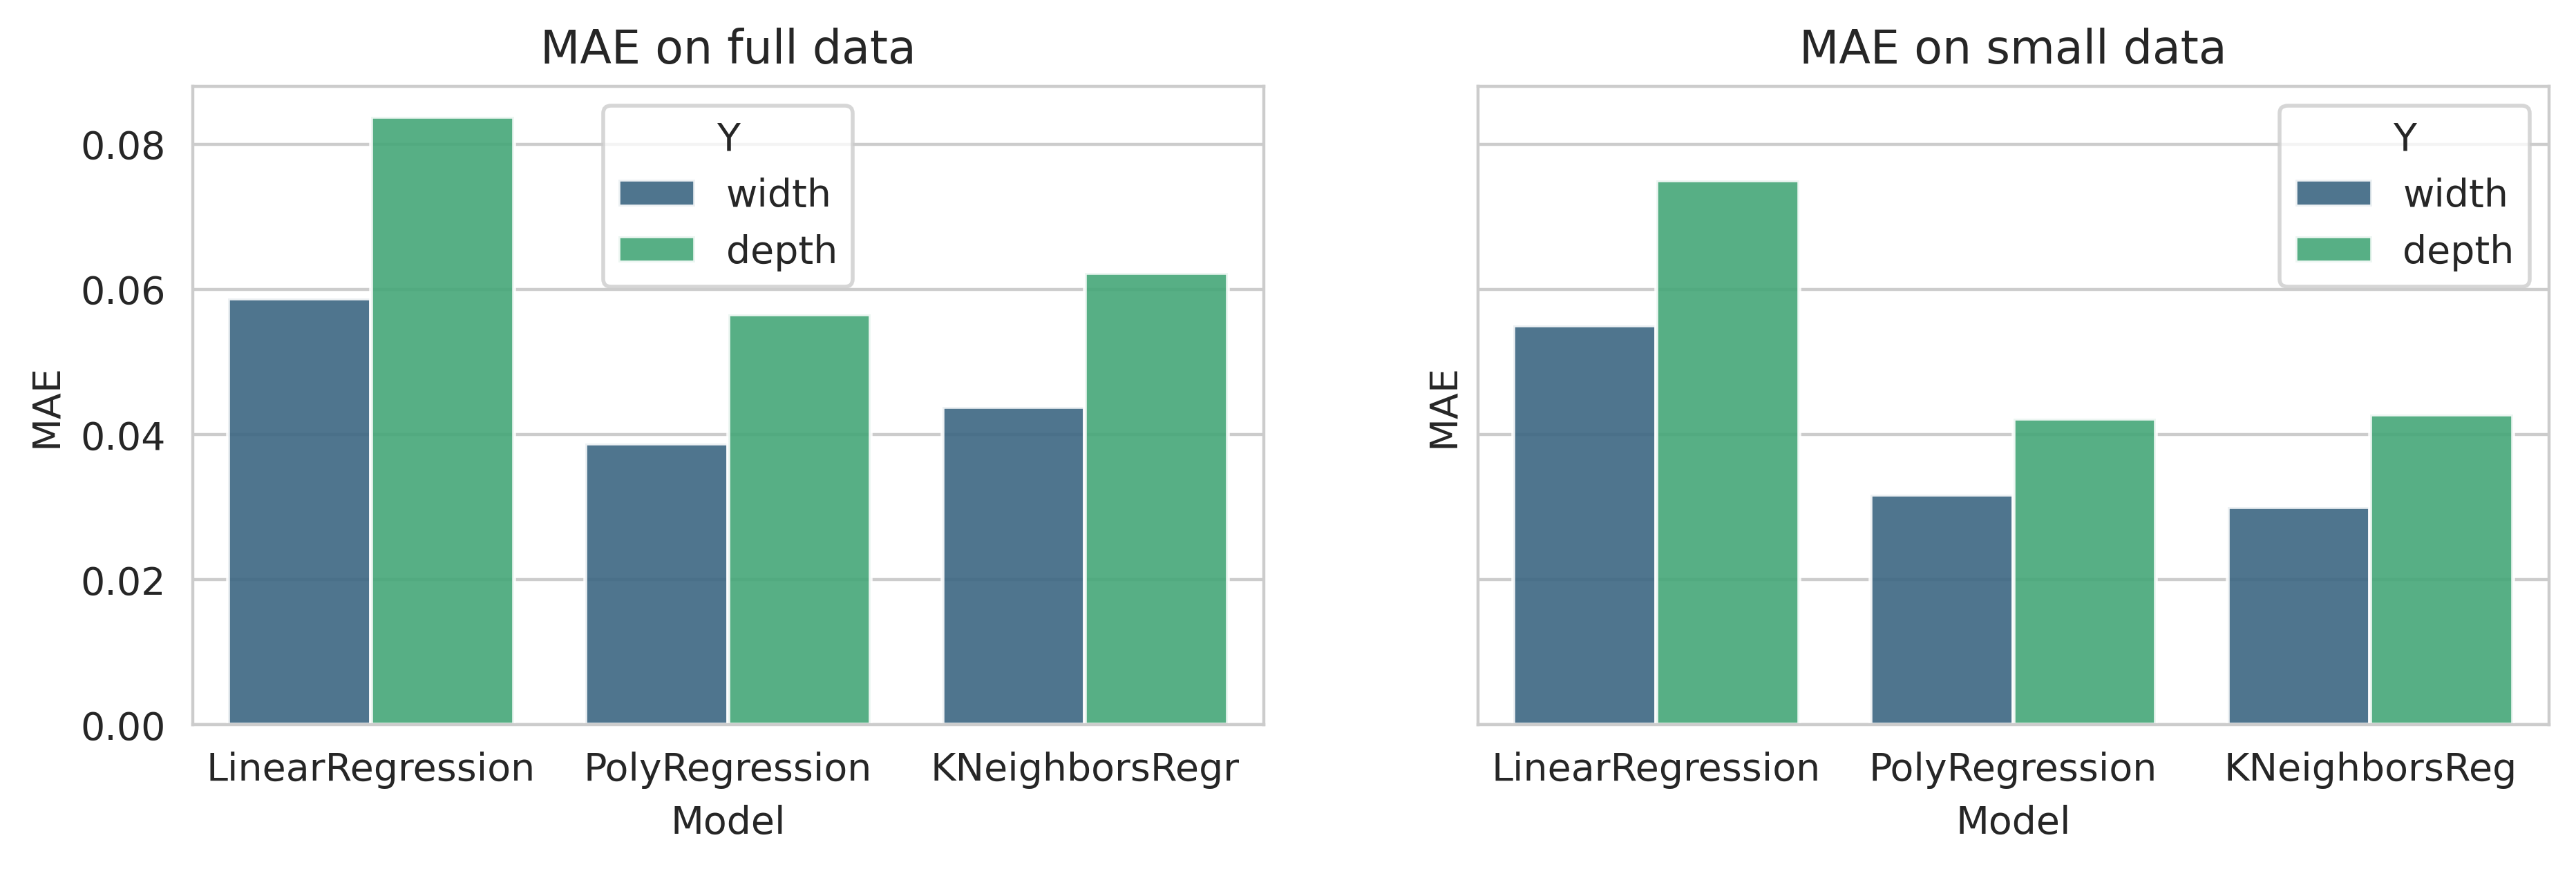

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3),dpi=400, sharey=True)
sns.barplot(ax=axes[0],data=m_Q.where(m_Q.Data=='full'),x='Model',y='MAE',hue='Y',palette = "viridis",alpha=0.9)
axes[0].set_title("MAE on full data")
sns.barplot(ax=axes[1],data=m_Q.where(m_Q.Data=='small'),x='Model',y='MAE',hue='Y',palette = "viridis",alpha=0.9)
axes[1].set_title("MAE on small data")

In [ ]:
std_w=data.groupby(['IW','IF','VW','FP']).agg('std').Width.mean()
std_d=data.groupby(['IW','IF','VW','FP']).agg('std').Depth.mean()
print(f'Стандартное отклонение в значениях Depth = {std_d}')
print(f'Стандартное отклонение в значениях Width = {std_w}')
# напомним стандартные отклонения значений зависимых переменных при одних и тех же предикторах

Стандартное отклонение в значениях Depth = 0.046208463031442756
Стандартное отклонение в значениях Width = 0.03555737132726758


Предварительно мы видим, что предсказательная способность модели неплохая,вс
MAE начинается со свторого знака после запятой как и среднеквадратичное отклонение в данных <i>(при одних и тех же предикторах)</i> и даже есть модель c MAE чуть меньше данных отклонений а именно Полиномиальная Регрессия обученная на "маленьких" данных, но проверенная на сотне тестовых выборок из основного датасета. С другой стороны лучшая работа "маленького" датасета может быть объяснена тем, что в нашем дизайне построения моделей он не разбивается на тестовую и тренинговую выборку, а обучается на всех данных, проверить надежность данной модели можно изаользуя отложеенные данные, которых модель не увидит. Делать вид, что модели обученные на всём датасете надёжней тоже не стоит, хотя в них есть тест трейн спплит, мы помним, что все из возможных 15 последовательностей параметров попадают к нам в train выборку, и модель фактически не видит новых данных на тесте! <i>(об этом же свидетельсnвует, то что модель полного датасета ломается на множественных инерациях полиномиальной регрессии)</i>

Так выберем же одну из наших лучших предсказательных моделей, и проведём эесперимент насколько она устойчива к неведанным данным! LeaveOneOut Cross Validation может ответить нам на данный вопрос 

In [ ]:
from sklearn.model_selection import LeaveOneOut

In [ ]:
# Лив уан оут на линейной регрессии
cv = LeaveOneOut()
model = LinearRegression()
scores_w = cross_val_score(model, Xs, ys_w, scoring='neg_mean_absolute_error',
                         cv=cv)
scores_d = cross_val_score(model, Xs, ys_d, scoring='neg_mean_absolute_error',
                         cv=cv)
#MAE
mae_w,mae_d=np.mean(abs(scores_w)),np.mean(abs(scores_d))
print(f"MAE ширины равна {round(mae_w,4)}\nMAE глубины равна {round(mae_d,4)}")


MAE ширины равна 0.0751
MAE глубины равна 0.1155


In [ ]:
# Лив уан оут на полиномиальной регрессии
poly_Xs = poly.fit_transform(Xs)
cv = LeaveOneOut()
model = LinearRegression()
scores_w = cross_val_score(model, poly_Xs, ys_w, scoring='neg_mean_absolute_error',
                         cv=cv)
scores_d = cross_val_score(model, poly_Xs, ys_d, scoring='neg_mean_absolute_error',
                         cv=cv)
#MAE
mae_w,mae_d=np.mean(abs(scores_w)),np.mean(abs(scores_d))
print(f"MAE ширины равна {round(mae_w,4)}\nMAE глубины равна {round(mae_d,4)}")

MAE ширины равна 0.1986
MAE глубины равна 0.4548


Как и ожидалось качество модели сильно упало, однако предсказание ширины обычной
линейной моделью даёт довольно неплохие результаты <b>.0751</b>, что говорит о том, что модель в целом неплохая и нашла какие-то зависимости, а вот над предсказание глубины ещё можно поработать

Поработаем, для этого используем предсказанный параметр Ширины шва в качестве предиктора для Глубины шва

In [ ]:
cv = LeaveOneOut()
model = LinearRegression()
scores_w = cross_val_score(model, Xs, ys_w, scoring='neg_mean_absolute_error',
                         cv=cv)
print("MAE of Width =", np.mean(abs(scores_w)))
reg=model.fit(Xs, ys_w)# Xs
w_pred=reg.predict(Xs)

dta=pd.DataFrame(Xs)
dta['P_w']=w_pred
newX=min_max_scaler.fit_transform(np.array(dta))

MAE of Width = 0.07508825722543902


In [ ]:
scores_d = cross_val_score(model, newX, ys_d, scoring='neg_mean_absolute_error',
                         cv=cv)
print("MAE of Depth =",np.mean(abs(scores_d))) # нам удалось незначительно улучшить качетсво модели

MAE of Depth = 0.11550608440286997


Таким образом  получилось немного улучшить предсказание Глубины.</div>

 <h3>V. Вывод</h3>
    Нам попался увлекательный датсает, в котором одни и те же последовательности независимых переменных имёют различное значение зависимой, проблема обучения данного датасета заключалась в правильной стратегии разбиения датасета на test train, поскольку нельзя было быть уверенным в том,  что мы исключили все из 15 имеющихся последовательностей в независимых переменных -> не факт что модель бы тестировалась на неизвестных ей данных -> качество такой моделей весьма спорно, неизвестно как бы она повела себя на данных которых она не видела.

Тем не менее нам удалось построить модель сократив датасет до 15 наблюдений и на LeaveOneOut кросс валидации доказать состоятельность его оценок <i>(даже на неизвестных ему данных)</i> Итоговой средней абсолютной ошибкой для глубины шва стал показатель<b>.11</b>, для ширины <b>.07</b> результат удовлетворял требованиям заказчика</div>